# TSP exact par ILP (OR-Tools CP-SAT, formulation MTZ)

Génère un graphe aléatoire et résout le tour optimal.

> **Limite MTZ :** fiable jusqu'à ~50 villes. Au-delà, utiliser la formulation DFJ avec lazy constraints (Concorde).

In [3]:
## Imports
import math
import random
import time
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

## 1. Génération de graphe

In [4]:
def generate_graph(n: int, seed: int | None = None) -> list[tuple[float, float]]:
    """
    Génère n villes aléatoires dans un carré [0, 100] x [0, 100].
    Retourne une liste de tuples (x, y).
    """
    rng = random.Random(seed)
    return [(rng.uniform(0, 100), rng.uniform(0, 100)) for _ in range(n)]

## 2. Solveur ILP (formulation MTZ)

In [5]:
def solve_tsp_ilp(
    cities: list[tuple[float, float]],
    time_limit: float = 120.0,
) -> tuple[list[int], float, str]:
    """
    Résout le TSP exact via ILP (CP-SAT d'OR-Tools, formulation MTZ).

    Paramètres
    ----------
    cities      : liste de coordonnées (x, y)
    time_limit  : limite de temps en secondes

    Retourne
    --------
    tour        : ordre de visite des villes (indices)
    distance    : distance totale du tour
    status      : "OPTIMAL" | "FEASIBLE" | "INFEASIBLE"
    """
    n = len(cities)

    def dist(i: int, j: int) -> int:
        dx = cities[i][0] - cities[j][0]
        dy = cities[i][1] - cities[j][1]
        return int(math.hypot(dx, dy) * 1000)  # ×1000 pour garder la précision entière

    model = cp_model.CpModel()

    # Variables de décision
    x = [[model.new_bool_var(f"x_{i}_{j}") for j in range(n)] for i in range(n)]
    u = [model.new_int_var(0, n - 1, f"u_{i}") for i in range(n)]

    # Contraintes de degré
    for i in range(n):
        model.add(x[i][i] == 0)
        model.add(sum(x[i][j] for j in range(n) if j != i) == 1)  # quitter i une fois
        model.add(sum(x[j][i] for j in range(n) if j != i) == 1)  # arriver en i une fois

    # Contraintes MTZ (anti sous-tours)
    model.add(u[0] == 0)
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                model.add(u[i] - u[j] + n * x[i][j] <= n - 1)

    # Objectif
    model.minimize(
        sum(dist(i, j) * x[i][j] for i in range(n) for j in range(n) if i != j)
    )

    # Résolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit

    status_code = solver.solve(model)
    status_map = {
        cp_model.OPTIMAL: "OPTIMAL",
        cp_model.FEASIBLE: "FEASIBLE",
        cp_model.INFEASIBLE: "INFEASIBLE",
        cp_model.UNKNOWN: "UNKNOWN",
    }
    status = status_map.get(status_code, "UNKNOWN")

    if status_code not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return [], float("inf"), status

    # Reconstruction du tour
    tour = [0]
    current = 0
    for _ in range(n - 1):
        current = next(
            j for j in range(n) if j != current and solver.value(x[current][j]) == 1
        )
        tour.append(current)

    total = (
        sum(dist(tour[k], tour[k + 1]) for k in range(n - 1))
        + dist(tour[-1], tour[0])
    ) / 1000

    return tour, total, status

## 3. Visualisation

In [6]:
def plot_tour(
    cities: list[tuple[float, float]],
    tour: list[int],
    distance: float,
    status: str,
) -> None:
    """Affiche le graphe et le tour optimal trouvé."""
    fig, ax = plt.subplots(figsize=(8, 8))

    # Arêtes du tour
    tour_closed = tour + [tour[0]]
    for k in range(len(tour_closed) - 1):
        i, j = tour_closed[k], tour_closed[k + 1]
        ax.plot(
            [cities[i][0], cities[j][0]],
            [cities[i][1], cities[j][1]],
            "b-", linewidth=1.2, alpha=0.7
        )

    # Villes
    xs = [c[0] for c in cities]
    ys = [c[1] for c in cities]
    ax.scatter(xs, ys, c="red", s=60, zorder=5)
    for idx, (cx, cy) in enumerate(cities):
        ax.annotate(str(idx), (cx, cy), textcoords="offset points",
                    xytext=(5, 5), fontsize=8)

    # Départ
    ax.scatter([cities[tour[0]][0]], [cities[tour[0]][1]],
               c="green", s=120, zorder=6, label="Départ")

    ax.set_title(f"TSP ILP — {len(cities)} villes | Distance : {distance:.2f} | {status}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Paramètres — modifie ici

In [7]:
N_CITIES_LIST = [1, 10, 100, 1_000, 10_000, 100_000]
SEED          = 42
TIME_LIMIT    = 30.0   # secondes max par instance

## 5. Exécution


  n = 1 villes
  Statut   : INFEASIBLE
  Tour     : []
  Distance : —
  Temps    : 0.00s

  n = 10 villes
  Statut   : OPTIMAL
  Tour     : [0, 9, 3, 7, 2, 8, 5, 6, 1, 4]
  Distance : 264.134
  Temps    : 0.02s


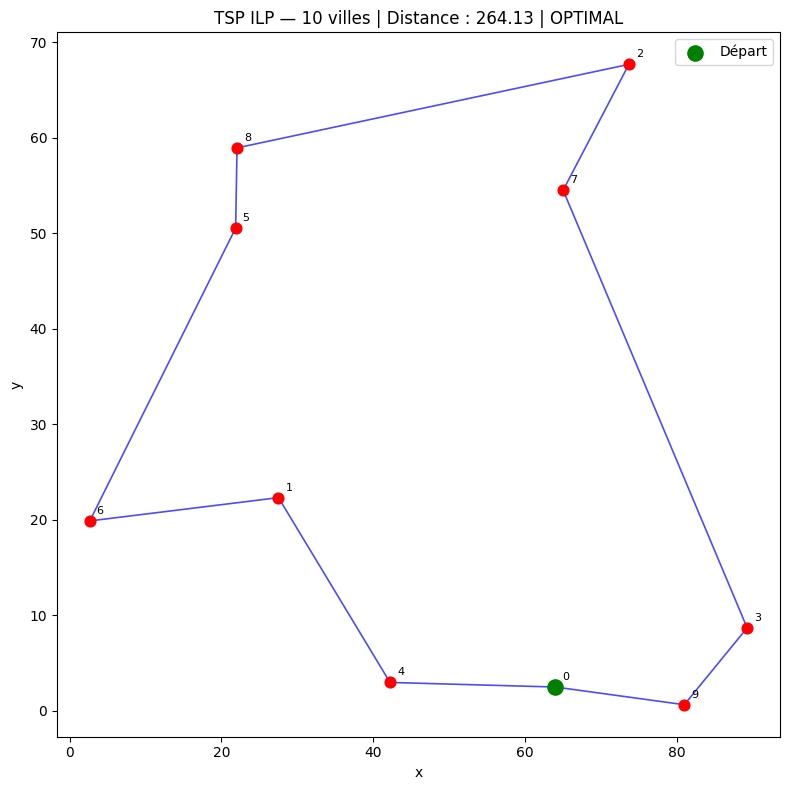


  n = 100 villes
  Statut   : FEASIBLE
  Tour     : [0, 98, 59, 56, 40, 24, 37, 46, 61, 60, 51, 7, 70, 76, 89, 17, 78, 58, 52, 83, 8, 5, 94, 53, 88, 47, 62, 23, 77, 22, 6, 13, 44, 84, 33, 65, 4, 11, 25, 42, 72, 95, 92, 34, 39, 1, 79, 21, 74, 29, 67, 80, 45, 28, 68, 50, 63, 35, 26, 96, 81, 71, 97, 54, 16, 41, 86, 73, 31, 27, 90, 2, 10, 15, 32, 64, 66, 57, 49, 99, 75, 30, 18, 14, 19, 85, 48, 43, 38, 12, 36, 55, 93, 87, 69, 91, 3, 82, 9, 20]
  Distance : 810.300
  Temps    : 31.30s


In [ ]:
for N_CITIES in N_CITIES_LIST:
    print(f"\n{'='*55}")
    print(f"  n = {N_CITIES:,} villes")
    print(f"{'='*55}")

    cities = generate_graph(N_CITIES, seed=SEED)

    t0 = time.perf_counter()
    tour, distance, status = solve_tsp_ilp(cities, time_limit=TIME_LIMIT)
    elapsed = time.perf_counter() - t0

    print(f"  Statut   : {status}")
    print(f"  Tour     : {tour}")
    print(f"  Distance : {distance:.3f}" if distance != float("inf") else "  Distance : —")
    print(f"  Temps    : {elapsed:.2f}s")

    if tour:
        plot_tour(cities, tour, distance, status)

## 6. Benchmark — performances selon le nombre de villes

Mesure le temps de résolution, la distance trouvée et le statut pour chaque taille.
MTZ devient impraticable au-delà de ~50 villes (explosion combinatoire O(n²) contraintes).

In [ ]:
import tracemalloc

BENCHMARK_SIZES   = [1, 10, 100, 1_000, 10_000, 100_000]
BENCHMARK_SEED    = 42
TIME_LIMIT_BM     = 30.0   # secondes max par instance
MODEL_BUILD_LIMIT = 300    # au-delà MTZ est trop lourd (n² variables)

results = []

for n in BENCHMARK_SIZES:
    print(f"[n={n:>7}] ", end="", flush=True)

    if n > MODEL_BUILD_LIMIT:
        print(f"SKIP — modèle MTZ trop lourd ({n}² = {n**2:,} variables)")
        results.append({"n": n, "statut": "SKIP", "distance": None, "temps": None, "memoire": None})
        continue

    cities = generate_graph(n, seed=BENCHMARK_SEED)
    tracemalloc.start()
    t0 = time.perf_counter()
    try:
        tour, distance, status = solve_tsp_ilp(cities, time_limit=TIME_LIMIT_BM)
    except Exception as e:
        elapsed = time.perf_counter() - t0
        tracemalloc.stop()
        print(f"ERREUR — {e}")
        results.append({"n": n, "statut": "ERREUR", "distance": None, "temps": elapsed, "memoire": None})
        continue

    elapsed = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    dist_val = distance if distance != float("inf") else None
    mem_mb   = peak / 1e6
    print(f"{status:<10}  distance={dist_val}  temps={elapsed:.2f}s  mém={mem_mb:.1f} MB")
    results.append({"n": n, "statut": status, "distance": dist_val, "temps": elapsed, "memoire": mem_mb})

[n=      1] 

INFEASIBLE  distance=None  temps=0.00s  mém=0.0 MB
[n=     10] 

OPTIMAL     distance=264.134  temps=0.04s  mém=0.0 MB
[n=    100] 

FEASIBLE    distance=837.216  temps=30.52s  mém=1.0 MB
[n=   1000] 

SKIP — modèle MTZ trop lourd (1000² = 1,000,000 variables)
[n=  10000] 

SKIP — modèle MTZ trop lourd (10000² = 100,000,000 variables)
[n= 100000] 

SKIP — modèle MTZ trop lourd (100000² = 10,000,000,000 variables)


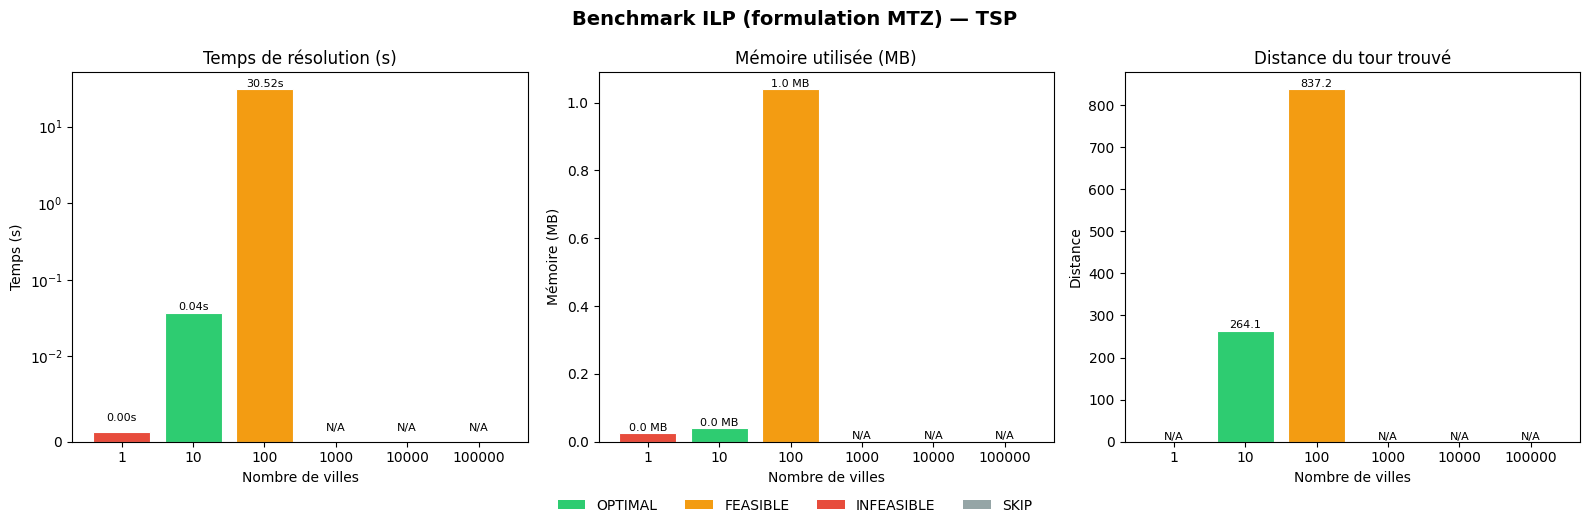

In [ ]:
labels  = [str(r["n"]) for r in results]
statuts = [r["statut"] for r in results]
temps   = [r["temps"]   if r["temps"]   is not None else 0 for r in results]
memoire = [r["memoire"] if r["memoire"] is not None else 0 for r in results]
dists   = [r["distance"] if r["distance"] is not None else 0 for r in results]

COLOR_MAP = {"OPTIMAL": "#2ecc71", "FEASIBLE": "#f39c12", "INFEASIBLE": "#e74c3c",
             "SKIP": "#95a5a6", "ERREUR": "#c0392b", "UNKNOWN": "#9b59b6"}
colors = [COLOR_MAP.get(s, "#bdc3c7") for s in statuts]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Benchmark ILP (formulation MTZ) — TSP", fontsize=14, fontweight="bold")

# ── Graphique 1 : Temps de résolution ──
ax = axes[0]
bars = ax.bar(labels, temps, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Temps de résolution (s)")
ax.set_xlabel("Nombre de villes")
ax.set_ylabel("Temps (s)")
ax.set_yscale("symlog", linthresh=0.01)
for bar, r in zip(bars, results):
    label = f"{r['temps']:.2f}s" if r["temps"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            label, ha="center", va="bottom", fontsize=8)

# ── Graphique 2 : Mémoire utilisée ──
ax = axes[1]
bars = ax.bar(labels, memoire, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Mémoire utilisée (MB)")
ax.set_xlabel("Nombre de villes")
ax.set_ylabel("Mémoire (MB)")
for bar, r in zip(bars, results):
    label = f"{r['memoire']:.1f} MB" if r["memoire"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            label, ha="center", va="bottom", fontsize=8)

# ── Graphique 3 : Distance trouvée ──
ax = axes[2]
bars = ax.bar(labels, dists, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Distance du tour trouvé")
ax.set_xlabel("Nombre de villes")
ax.set_ylabel("Distance")
for bar, r in zip(bars, results):
    label = f"{r['distance']:.1f}" if r["distance"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            label, ha="center", va="bottom", fontsize=8)

# ── Légende commune ──
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in COLOR_MAP.items() if s in statuts]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(legend_elements),
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
plt.show()

## 7. Prédiction des temps d'exécution pour grandes instances

Basé sur les mesures réelles (n=10 → 0.02s, n=100 → 30s), on ajuste une **loi de puissance** `t = a × nᵇ` pour prédire les temps à 1 000, 10 000 et 100 000 villes.

In [ ]:
import numpy as np

# ── Données mesurées (n, temps en secondes) ──
# n=1  → INFEASIBLE, pas de temps significatif
# n=10 → OPTIMAL    0.02s
# n=100→ FEASIBLE   30s (limite atteinte — borne basse réelle)
known_n = np.array([10, 100])
known_t = np.array([0.02, 30.0])

# ── Fit loi de puissance : log(t) = log(a) + b*log(n) ──
b, log_a = np.polyfit(np.log(known_n), np.log(known_t), 1)
a = np.exp(log_a)
print(f"Modèle ajusté : t = {a:.4e} × n^{b:.3f}")

# ── Prédictions ──
targets = [1_000, 10_000, 100_000]

def format_seconds(s):
    if s < 60:
        return f"{s:.1f}s"
    elif s < 3600:
        return f"{s/60:.1f} min"
    elif s < 86400:
        return f"{s/3600:.1f} h"
    elif s < 86400 * 365:
        return f"{s/86400:.1f} jours"
    else:
        return f"{s/(86400*365):.1f} ans"

print(f"\n{'n':>10} | {'Temps prédit':>15} | {'Valeur brute':>20}")
print("-" * 52)
for n in targets:
    t_pred = a * n ** b
    print(f"{n:>10,} | {format_seconds(t_pred):>15} | {t_pred:>18.2e} s")

# ── Graphique ──
n_range = np.logspace(1, 6, 300)
t_range = a * n_range ** b

fig, ax = plt.subplots(figsize=(10, 5))

# Courbe de prédiction
ax.plot(n_range, t_range, "b-", linewidth=2, label=f"Modèle : t = {a:.2e} × n^{b:.2f}")

# Points mesurés
ax.scatter(known_n, known_t, color="green", s=100, zorder=5, label="Mesures réelles")
for n, t in zip(known_n, known_t):
    ax.annotate(f"n={n:,}\n{format_seconds(t)}", (n, t),
                textcoords="offset points", xytext=(10, 5), fontsize=9, color="green")

# Points prédits
pred_t = [a * n ** b for n in targets]
ax.scatter(targets, pred_t, color="red", s=100, marker="x", zorder=5, linewidths=2,
           label="Prédictions")
for n, t in zip(targets, pred_t):
    ax.annotate(f"n={n:,}\n{format_seconds(t)}", (n, t),
                textcoords="offset points", xytext=(10, -15), fontsize=9, color="red")

# Lignes de référence temporelles
for label, seconds, color in [("1 min", 60, "orange"), ("1 h", 3600, "tomato"), ("1 jour", 86400, "purple")]:
    ax.axhline(seconds, linestyle="--", color=color, alpha=0.6, linewidth=1)
    ax.text(n_range[-1], seconds * 1.1, label, color=color, fontsize=8, ha="right")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Nombre de villes (n)", fontsize=11)
ax.set_ylabel("Temps de résolution (s)", fontsize=11)
ax.set_title("Prédiction du temps ILP (MTZ) par extrapolation — loi de puissance", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. ILP — Formulation DFJ avec Lazy Constraints

Au lieu de pré-charger toutes les contraintes anti sous-tours (MTZ), la formulation DFJ les ajoute **à la volée** :
1. Résoudre sans contraintes anti sous-tours
2. Détecter les sous-tours dans la solution
3. Ajouter une coupe DFJ par sous-tour détecté : $\sum_{i,j \in S} x_{ij} \leq |S| - 1$
4. Relancer — répéter jusqu'à obtenir un tour unique

Avantage : beaucoup moins de contraintes en mémoire, meilleure relaxation LP.

In [1]:
def find_subtours(n: int, x_val: list[list[int]]) -> list[list[int]]:
    """Détecte tous les sous-tours dans une solution binaire."""
    visited = [False] * n
    subtours = []
    for start in range(n):
        if visited[start]:
            continue
        tour, current = [], start
        while not visited[current]:
            visited[current] = True
            tour.append(current)
            nxt = next((j for j in range(n) if x_val[current][j] > 0.5), None)
            if nxt is None:
                break
            current = nxt
        subtours.append(tour)
    return subtours


def solve_tsp_dfj(
    cities: list[tuple[float, float]],
    time_limit: float = 120.0,
) -> tuple[list[int], float, int, int]:
    """
    Résout le TSP exact via ILP DFJ avec lazy constraints (CP-SAT itératif).

    Retourne : (tour, distance, nb_iterations, nb_coupes)
    """
    n = len(cities)

    def dist(i: int, j: int) -> int:
        dx = cities[i][0] - cities[j][0]
        dy = cities[i][1] - cities[j][1]
        return int(math.hypot(dx, dy) * 1000)

    forbidden: list[frozenset] = []   # coupes DFJ accumulées
    iteration = 0

    while True:
        iteration += 1
        model = cp_model.CpModel()
        x = [[model.new_bool_var(f"x_{i}_{j}") for j in range(n)] for i in range(n)]

        # Contraintes de degré
        for i in range(n):
            model.add(x[i][i] == 0)
            model.add(sum(x[i][j] for j in range(n) if j != i) == 1)
            model.add(sum(x[j][i] for j in range(n) if j != i) == 1)

        # Coupes DFJ accumulées
        for S in forbidden:
            S_list = list(S)
            model.add(sum(x[i][j] for i in S_list for j in S_list if i != j) <= len(S_list) - 1)

        # Objectif
        model.minimize(
            sum(dist(i, j) * x[i][j] for i in range(n) for j in range(n) if i != j)
        )

        solver = cp_model.CpSolver()
        solver.parameters.max_time_in_seconds = time_limit
        status_code = solver.solve(model)

        if status_code not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
            return [], float("inf"), iteration, len(forbidden)

        x_val = [[solver.value(x[i][j]) for j in range(n)] for i in range(n)]
        subtours = find_subtours(n, x_val)

        print(f"  Itération {iteration:>2} — {len(subtours)} cycle(s) détecté(s)", end="")

        if len(subtours) == 1:
            print(" → tour unique, solution valide ✓")
            break

        # Ajouter une coupe par sous-tour
        new_cuts = 0
        for st in subtours:
            fs = frozenset(st)
            if fs not in forbidden and len(fs) < n:
                forbidden.append(fs)
                new_cuts += 1
        print(f"  — {new_cuts} coupe(s) ajoutée(s) (total : {len(forbidden)})")

    tour = subtours[0]
    total = (
        sum(dist(tour[k], tour[k + 1]) for k in range(n - 1))
        + dist(tour[-1], tour[0])
    ) / 1000

    return tour, total, iteration, len(forbidden)

=== Test ILP DFJ (lazy constraints) ===

     n |  iter |  coupes |   distance |    temps | MTZ distance
-----------------------------------------------------------------

[DFJ  n=10]
  Itération  1 — 5 cycle(s) détecté(s)  — 5 coupe(s) ajoutée(s) (total : 5)
  Itération  2 — 1 cycle(s) détecté(s) → tour unique, solution valide ✓
  Résultat : 2 iter | 5 coupes | dist=264.13 | t=0.03s
  MTZ      : dist=264.13 | t=0.02s


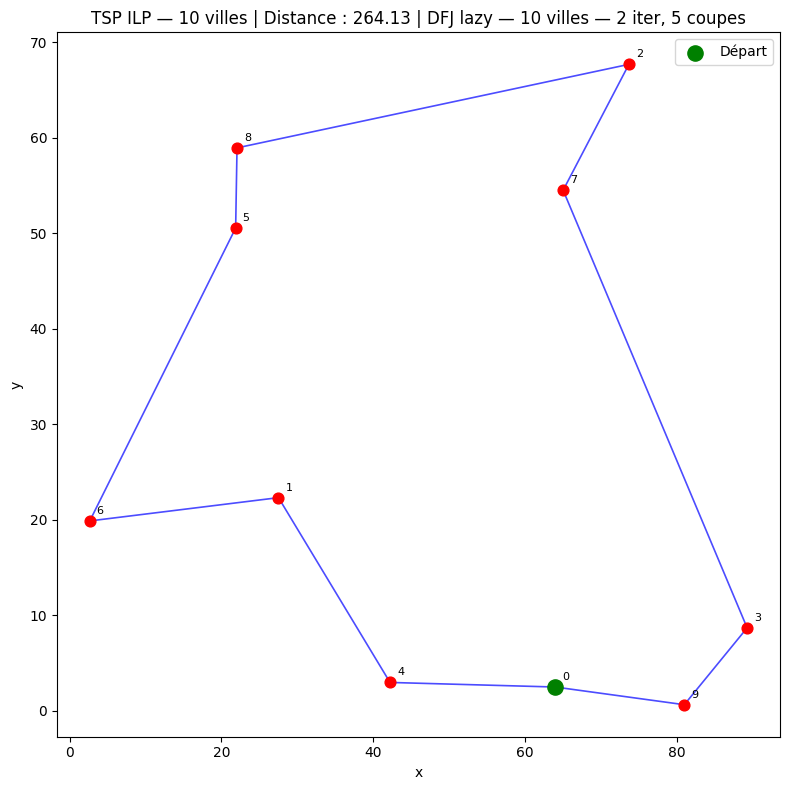


[DFJ  n=100]
  Itération  1 — 47 cycle(s) détecté(s)  — 47 coupe(s) ajoutée(s) (total : 47)
  Itération  2 — 16 cycle(s) détecté(s)  — 16 coupe(s) ajoutée(s) (total : 63)
  Itération  3 — 9 cycle(s) détecté(s)  — 9 coupe(s) ajoutée(s) (total : 72)
  Itération  4 — 9 cycle(s) détecté(s)  — 9 coupe(s) ajoutée(s) (total : 81)
  Itération  5 — 3 cycle(s) détecté(s)  — 3 coupe(s) ajoutée(s) (total : 84)
  Itération  6 — 1 cycle(s) détecté(s) → tour unique, solution valide ✓
  Résultat : 6 iter | 84 coupes | dist=792.05 | t=24.56s
  MTZ      : dist=811.64 | t=60.32s


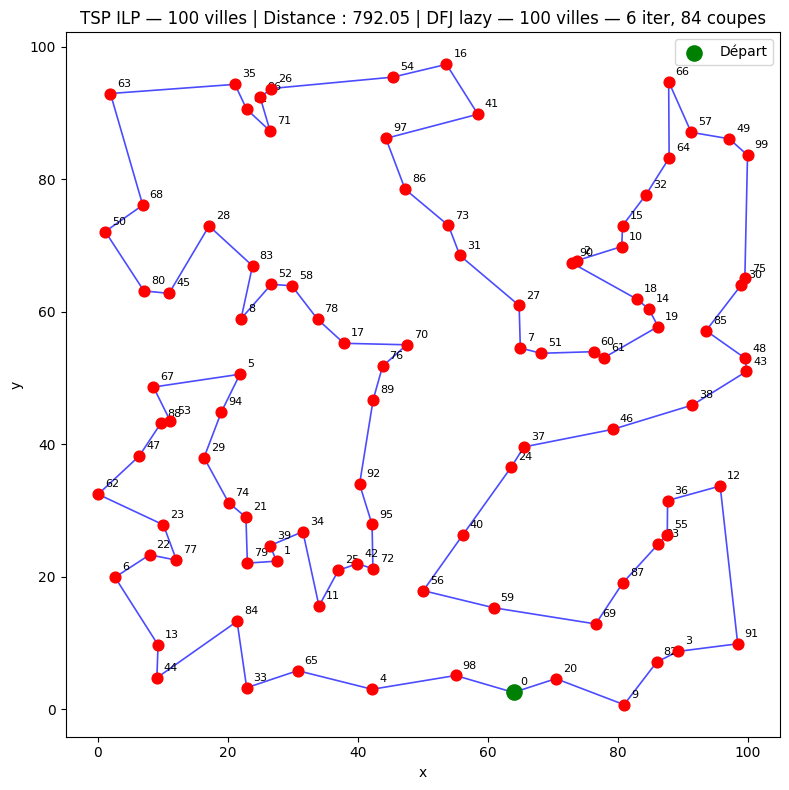


[DFJ  n=1000]
  Itération  1 — 500 cycle(s) détecté(s)  — 500 coupe(s) ajoutée(s) (total : 500)
  Itération  2 — 96 cycle(s) détecté(s)  — 96 coupe(s) ajoutée(s) (total : 596)
  Itération  3 — 77 cycle(s) détecté(s)  — 77 coupe(s) ajoutée(s) (total : 673)
  Résultat : 4 iter | 673 coupes | dist=— | t=314.16s
  MTZ      : dist=— | t=91.53s

[DFJ  n=10000]


In [ ]:
DFJ_SIZES  = [10, 100, 1000, 10000, 100000]
DFJ_SEED   = 42
DFJ_LIMIT  = 60.0

print("=== Test ILP DFJ (lazy constraints) ===\n")
print(f"{'n':>6} | {'iter':>5} | {'coupes':>7} | {'distance':>10} | {'temps':>8} | MTZ distance")
print("-" * 65)

for n in DFJ_SIZES:
    cities = generate_graph(n, seed=DFJ_SEED)

    # DFJ
    print(f"\n[DFJ  n={n}]")
    t0 = time.perf_counter()
    tour_dfj, dist_dfj, iters, cuts = solve_tsp_dfj(cities, time_limit=DFJ_LIMIT)
    t_dfj = time.perf_counter() - t0

    # MTZ pour comparaison (même instance)
    t1 = time.perf_counter()
    tour_mtz, dist_mtz, _ = solve_tsp_ilp(cities, time_limit=DFJ_LIMIT)
    t_mtz = time.perf_counter() - t1

    dist_dfj_str = f"{dist_dfj:.2f}" if dist_dfj != float("inf") else "—"
    dist_mtz_str = f"{dist_mtz:.2f}" if dist_mtz != float("inf") else "—"

    print(f"  Résultat : {iters} iter | {cuts} coupes | dist={dist_dfj_str} | t={t_dfj:.2f}s")
    print(f"  MTZ      : dist={dist_mtz_str} | t={t_mtz:.2f}s")

    if tour_dfj:
        plot_tour(cities, tour_dfj, dist_dfj, f"DFJ lazy — {n} villes — {iters} iter, {cuts} coupes")